In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score , classification_report
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


C:\Users\vivek\anaconda4\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df = df.drop(columns=["Id"])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
(df == " ").sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [7]:
X = df.drop("Species", axis = 1)
y = df["Species"]

In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0,1,2


In [9]:
X_train, X_test , y_train, y_test = train_test_split(X,y_encoded, test_size = 0.2, stratify = y_encoded, random_state =42)

In [10]:
numerical_features = X.columns.tolist()
print(numerical_features)

['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ]
)

In [12]:
pipe_lr = Pipeline(steps = [
    ('preprocess',preprocessor),
    ('model',LogisticRegression(max_iter = 200))
])

pipe_xgb = Pipeline(steps = [
    ('preprocess',preprocessor),
    ('model',XGBClassifier(eval_metric = 'mlogloss'))
])
pipe_rf = Pipeline(steps=[
    ('preprocess',preprocessor),
    ('model',RandomForestClassifier())
])
pipe_dt = Pipeline(steps=[
    ('preprocess',preprocessor),
    ('model',DecisionTreeClassifier())
])

In [ ]:
"""
#ALTERNATIVE 1 FOR THE ABOVE SNIPPET
models = {
    "lr": LogisticRegression(max_iter=200),
    "dt": DecisionTreeClassifier(),
    "rf": RandomForestClassifier(),
    "xgb": XGBClassifier(eval_metric="mlogloss")
}

pipelines = {
    name: Pipeline([("preprocess", preprocessor), ("model", model)])
    for name, model in models.items()
}

# ALTERNATIVE 2 
def make_pipeline(model):
    return Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])

pipe_lr  = make_pipeline(LogisticRegression(max_iter=200))
pipe_dt  = make_pipeline(DecisionTreeClassifier())
pipe_rf  = make_pipeline(RandomForestClassifier())
pipe_xgb = make_pipeline(XGBClassifier(eval_metric="mlogloss"))
"""

In [13]:
models = {
    "Logistic Regression": pipe_lr,
    "Random Forest": pipe_rf,
    "XGBoost" : pipe_xgb,
    "Decision Tree": pipe_dt
}
cv_results = {}
for name,model in models.items():
    scores = cross_val_score(model, X_train,y_train, cv=5)
    cv_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.9583
Random Forest: 0.9583
XGBoost: 0.9500
Decision Tree: 0.9417


In [14]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs'],
    'model__max_iter': [200, 500]
}

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)


Best Logistic Regression params: {'model__C': 10, 'model__max_iter': 200, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Accuracy: 0.9666666666666668


In [15]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 2, 4, 6],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=5)
grid_rf.fit(X_train, y_train)

print("Best Random Forest params:", grid_rf.best_params_)
print("Best CV Accuracy:", grid_rf.best_score_)


Best Random Forest params: {'model__max_depth': 6, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV Accuracy: 0.9666666666666668


In [16]:
print("Logistic Regression Best CV Accuracy:", grid_lr.best_score_)
print("Random Forest Best CV Accuracy:", grid_rf.best_score_)


Logistic Regression Best CV Accuracy: 0.9666666666666668
Random Forest Best CV Accuracy: 0.9666666666666668


In [17]:
best_model = grid_rf.best_estimator_  # or grid_lr.best_estimator_
final_preds = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report
print("Final Test Accuracy:", accuracy_score(y_test, final_preds))
print(classification_report(y_test, final_preds))


Final Test Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



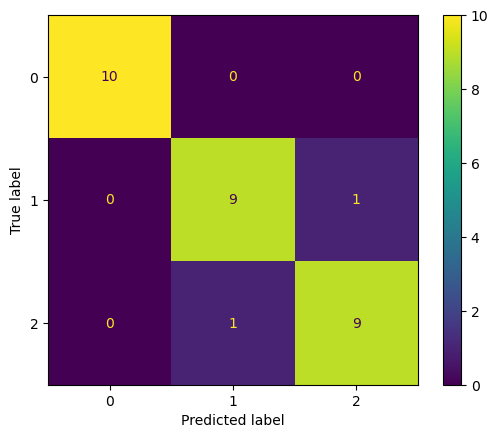

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)


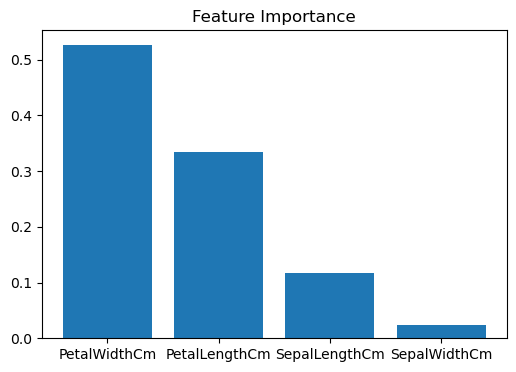

In [19]:
import matplotlib.pyplot as plt
import numpy as np

importances = best_model.named_steps['model'].feature_importances_
features = X.columns

indices = np.argsort(importances)[::-1]
plt.figure(figsize=(6,4))
plt.title("Feature Importance")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), [features[i] for i in indices])
plt.show()
